# 4 · Demo — the sieve closure as causal past (time is the signal)

Notebooks 02–03 showed a *model* limitation (1-WL can't read global structure).
This one shows something stronger — a *representation* limitation. Collapse a
stream of timestamped events into a static graph and you discard the **ordering**,
and ordering is the lateral-movement signal.

Both classes here share an **identical static-graph distribution**. Every stream
contains the same chain $f \to \dots \to g$, the same background traffic, and an
exfiltration event. Only the **timestamps of the chain** differ:

* **attack** — chain edges occur in increasing time order, so a *time-respecting*
  path $f \rightsquigarrow g$ exists and exfiltration follows.
* **benign** — the same edges occur scrambled, so no time-respecting path exists.

This reproduces `run_temporal.py`.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))   # repo root, so `import src...` works
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(precision=2, suppress=True)
plt.rcParams["figure.figsize"] = (7, 4)

## 4.1 · Two streams, same edges, different order

In [2]:
from src.temporal_data import make_stream, CHAIN, F, G

rng = np.random.default_rng(2)
attack = make_stream(True, rng)
benign = make_stream(False, rng)

def show_chain(stream, label):
    chain_edges = {(CHAIN[i], CHAIN[i+1]): None for i in range(len(CHAIN)-1)}
    times = {}
    for u, v, t in stream["events"]:
        if (u, v) in chain_edges: times[(u, v)] = t
    seq = [round(times[(CHAIN[i], CHAIN[i+1])], 2) for i in range(len(CHAIN)-1)]
    increasing = all(seq[i] < seq[i+1] for i in range(len(seq)-1))
    print(f"{label:8s} chain edge times f->...->g: {seq}   time-respecting? {increasing}")

print(f"chain: f={F} -> ... -> g={G},  exfil event leaves from g")
show_chain(attack, "attack")
show_chain(benign, "benign")
print("\nSame edges in both; only the chain's timestamps differ.")

chain: f=0 -> ... -> g=5,  exfil event leaves from g
attack   chain edge times f->...->g: [0.1, 0.11, 0.2, 0.69, 0.88]   time-respecting? True
benign   chain edge times f->...->g: [0.6, 0.18, 0.02, 0.83, 0.11]   time-respecting? False

Same edges in both; only the chain's timestamps differ.


## 4.2 · The temporal cover = time-respecting reachability = causal past

The temporal cover is computed by a single **time-ordered sweep**: process events
in increasing time, and let an event $(u,v,t)$ extend reachability to $v$ **iff**
$u$ is already reachable by time $t$. This is the temporal analogue of summing
powers of the adjacency — event order replaces multiplication order.

Categorically this is exact: the set of events that can reach a node along a
time-respecting path is its **causal past** — the sieve closure in the temporal
site.

In [3]:
from src.temporal_ops import temporal_arrivals, static_reachable

for label, stream in [("attack", attack), ("benign", benign)]:
    arr = temporal_arrivals(stream["events"])
    g_time = arr.get(G, np.inf)
    reached = G in arr and g_time < stream["t_exfil"]
    print(f"{label:8s}: g temporally reachable before exfil? {reached}   "
          f"(arrival(g)={g_time if np.isfinite(g_time) else 'never'}, exfil={stream['t_exfil']:.2f})")

print("\nStatically, though, g is ALWAYS reachable from f (the chain edges exist):")
for label, stream in [("attack", attack), ("benign", benign)]:
    print(f"  {label:8s}: g in static reachable set? {G in static_reachable(stream['events'])}")
print("-> the static graph cannot tell the classes apart; the temporal cover can.")

attack  : g temporally reachable before exfil? True   (arrival(g)=0.8844496736882935, exfil=1.27)
benign  : g temporally reachable before exfil? False   (arrival(g)=never, exfil=1.20)

Statically, though, g is ALWAYS reachable from f (the chain edges exist):
  attack  : g in static reachable set? True
  benign  : g in static reachable set? True
-> the static graph cannot tell the classes apart; the temporal cover can.


## 4.3 · Static models are pinned; the temporal cover recovers the signal

We compare three readers over many streams (base rate ~7% attacks):

* **static GCN** over the collapsed access graph,
* an **MLP on static reachability** features (v2),
* an **MLP on temporal cover** features.

The first two see only the static graph — identical across classes — so both are
stuck at the base rate. *(Reduced to one seed here for notebook speed; the script
averages three.)*

In [4]:
import torch
from sklearn.metrics import average_precision_score
from src.temporal_data import make_dataset
from src.temporal_ops import temporal_features, static_features
from src.temporal_models import stream_to_graph, make_mlp
from src.models import GCN

def oversample(X, y, rng):
    pos, neg = np.where(y == 1)[0], np.where(y == 0)[0]
    idx = rng.permutation(np.concatenate([neg, rng.choice(pos, len(neg))]))
    return X[idx], y[idx]

def mlp_ap(feat_fn, tr, ytr, te, yte, seed=0):
    rng = np.random.default_rng(seed)
    Xtr = np.array([feat_fn(s) for s in tr]); Xte = np.array([feat_fn(s) for s in te])
    Xb, yb = oversample(Xtr, ytr, rng)
    return average_precision_score(yte, make_mlp(seed).fit(Xb, yb).predict_proba(Xte)[:, 1])

def gcn_ap(tr, ytr, te, yte, seed=0):
    torch.manual_seed(seed)
    g  = [{"Phat": torch.from_numpy(P), "x": torch.from_numpy(x)} for P, x in map(stream_to_graph, tr)]
    gt = [{"Phat": torch.from_numpy(P), "x": torch.from_numpy(x)} for P, x in map(stream_to_graph, te)]
    m = GCN(in_dim=1, h=16); opt = torch.optim.Adam(m.parameters(), lr=1e-2, weight_decay=1e-4)
    pw = torch.tensor([(len(ytr) - ytr.sum()) / max(ytr.sum(), 1)], dtype=torch.float32)
    lossf = torch.nn.BCEWithLogitsLoss(pos_weight=pw); yt = torch.from_numpy(ytr.astype(np.float32))
    for _ in range(60):
        opt.zero_grad(); lossf(torch.stack([m(z).squeeze() for z in g]), yt).backward(); opt.step()
    with torch.no_grad():
        s = torch.stack([m(z).squeeze() for z in gt]).sigmoid().numpy()
    return average_precision_score(yte, s)

tr, ytr = make_dataset(n=1000, seed=0)
te, yte = make_dataset(n=1000, seed=500)
res = {"static GCN": gcn_ap(tr, ytr, te, yte),
       "MLP / static reach (v2)": mlp_ap(static_features, tr, ytr, te, yte),
       "MLP / TEMPORAL cover": mlp_ap(temporal_features, tr, ytr, te, yte)}

print(f"base rate: {yte.mean():.3f}\n")
print(f"{'model':26s} {'PR-AUC':>8s}")
print("-" * 36)
for k, v in res.items():
    print(f"{k:26s} {v:>8.3f}")

base rate: 0.063

model                        PR-AUC
------------------------------------
static GCN                    0.059
MLP / static reach (v2)       0.069
MLP / TEMPORAL cover          0.798


## 4.4 · A metric only time makes definable: lead time

Because we know *when* the time-respecting path completes, we can ask how long
**before exfiltration** the attack becomes visible — a quantity a static
classifier cannot even define.

attacks with a completed temporal path: 65   flagged before exfil: 100%


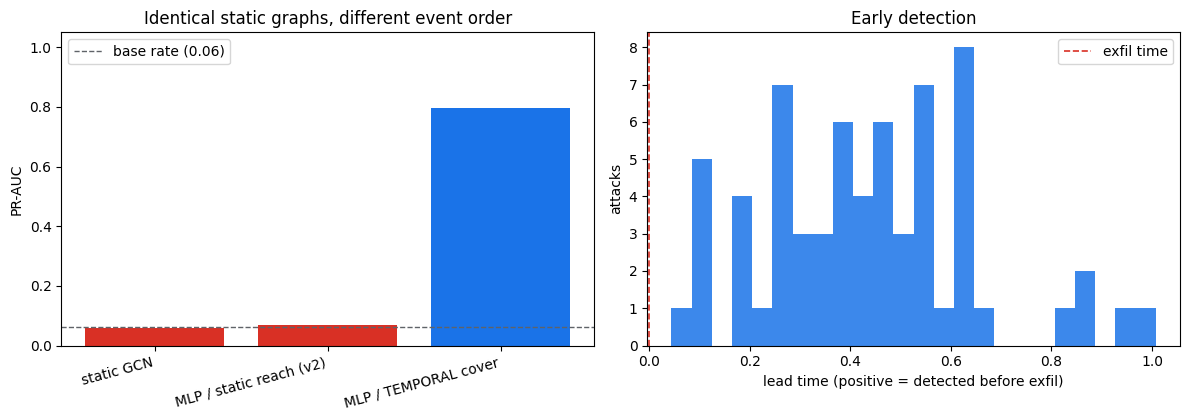

In [5]:
from src.temporal_ops import lead_time

te2, yte2 = make_dataset(n=1000, seed=999)
leads = np.array([lead_time(s) for s, yy in zip(te2, yte2) if yy == 1])
leads = leads[np.isfinite(leads)]
print(f"attacks with a completed temporal path: {len(leads)}   "
      f"flagged before exfil: {(leads > 0).mean():.0%}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.3))
names = list(res); vals = [res[n] for n in names]
ax1.bar(range(3), vals, color=["#d93025", "#d93025", "#1a73e8"])
ax1.axhline(yte.mean(), ls="--", lw=1, color="#5f6368", label=f"base rate ({yte.mean():.2f})")
ax1.set_xticks(range(3)); ax1.set_xticklabels(names, rotation=15, ha="right")
ax1.set_ylabel("PR-AUC"); ax1.set_ylim(0, 1.05); ax1.legend(loc="upper left")
ax1.set_title("Identical static graphs, different event order")

ax2.hist(leads, bins=24, color="#1a73e8", alpha=0.85)
ax2.axvline(0, ls="--", lw=1.2, color="#d93025", label="exfil time")
ax2.set_xlabel("lead time (positive = detected before exfil)"); ax2.set_ylabel("attacks")
ax2.legend(); ax2.set_title("Early detection")
plt.tight_layout(); plt.show()

## 4.5 · Takeaway

A static GCN and an MLP on static reachability are pinned at the ~7% base rate;
the same MLP on **temporal cover** features reaches PR-AUC ~0.8. It is not
perfect — and that is honest: the residual false positives are benign streams
whose scrambled chain is *coincidentally* time-increasing (about $1/5!$ of the
time), which event correlation, not reachability, would clean up.

**The arc of the three demos.** A cover is a *choice* of which subgraphs to
compose: the **reachability** cover exposes global blast radius (notebook 02), the
**sieve** cover reads local arrangement that defeats cospectrality (notebook 03),
and the **temporal** cover reads causal order (notebook 04). Designing a detector
becomes designing a cover — the Grothendieck GNN thesis, on a security task that
1-WL provably cannot solve.